In [2]:
!pip install datasets huggingface_hub --upgrade

# **1. Import Necessary Libraries**

In [3]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import cv2
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from huggingface_hub import hf_hub_download
from keras.metrics import Precision, Recall, AUC

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
# Downloads the zip file
zip_path = hf_hub_download(
    repo_id="seyeddd/multi_single_hotspots",
    filename="multi_single_hotspots.zip",       # the file in "Files and versions",
    repo_type="dataset"
)

# Extract to a local folder
extract_dir = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Check folder structure
os.listdir(extract_dir)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


['Dataset']

# **2. Image Preprocessing**

In [21]:
IMG_SIZE = (224,224)
BATCH_SIZE = 64
EPOCHS = 20

In [22]:
train_dir = "/content/dataset/Dataset/train"
valid_dir = "/content/dataset/Dataset/valid"
test_dir  = "/content/dataset/Dataset/test"

In [23]:
def preprocess(img):
    """
    Applies medical image specific preprocessing:
    - Grayscale conversion
    - Gaussian blur for noise reduction
    - Normalization
    """
    # Convert to grayscale if RGB
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    # Apply Gaussian Blur to reduce noise
    img_blurred = cv2.GaussianBlur(img_gray, ksize=(3,3), sigmaX=0)

    # Normalize to [0, 1]
    img_normalized = img_blurred / 255.0

    # Convert to 3 channels if needed
    if img_normalized.ndim == 2:
        img_normalized = np.stack([img_normalized]*3, axis=-1)

    return img_normalized


In [29]:
# Data generators to normalize the images
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=10,
    shear_range=0.01,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test generator (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess
)

In [30]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4923 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [31]:
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples: {test_gen.samples}")
print(f"Classes: {train_gen.class_indices}")

Training samples: 4923
Validation samples: 800
Test samples: 800
Classes: {'multi_hotspot': 0, 'single_hotspot': 1}


In [32]:
class_counts = Counter(train_gen.classes)
total_samples = sum(class_counts.values())
class_weights = {cls: total_samples/(len(class_counts)*count) for cls, count in class_counts.items()}
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

Class counts: Counter({np.int32(0): 3174, np.int32(1): 1749})
Class weights: {np.int32(0): 0.7755198487712666, np.int32(1): 1.4073756432246998}


In [33]:
synthetic_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=5,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='reflect'
)

synthetic_train_gen = synthetic_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

Found 4923 images belonging to 2 classes.


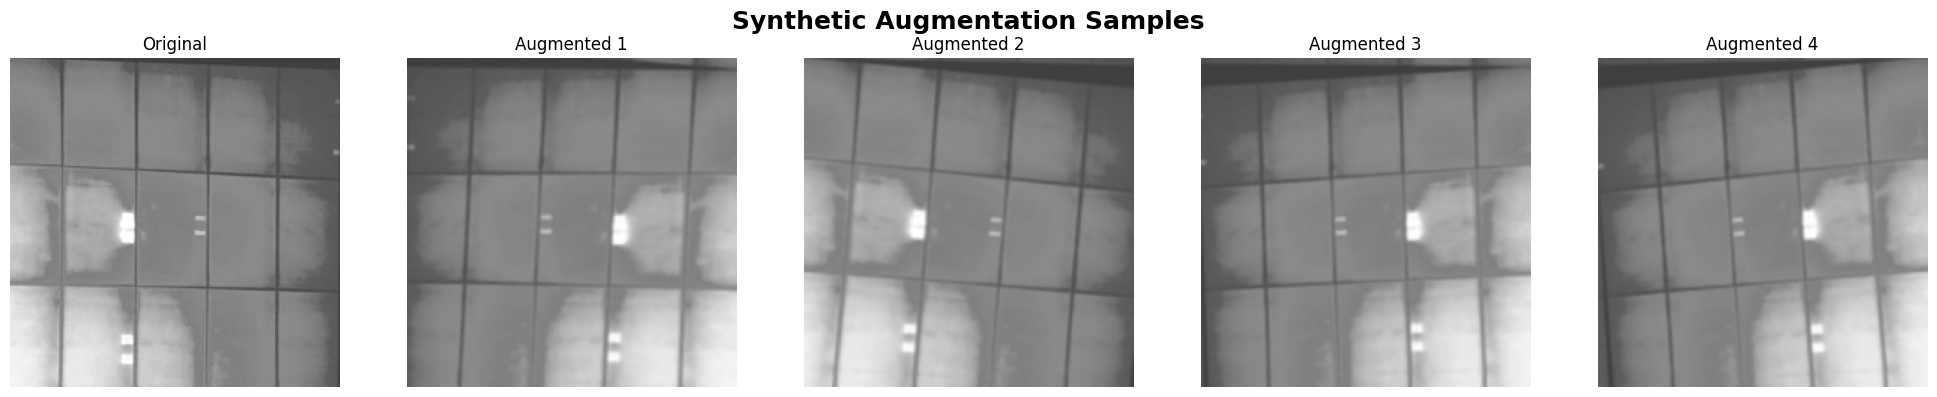

In [34]:
sample_img_path = os.path.join(train_dir, list(train_gen.class_indices.keys())[0],
                               os.listdir(os.path.join(train_dir, list(train_gen.class_indices.keys())[0]))[0])
sample_img = Image.open(sample_img_path).convert('RGB').resize(IMG_SIZE)
sample_array = np.expand_dims(np.array(sample_img), axis=0)

fig, axes = plt.subplots(1,5, figsize=(20,4))
axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')

for i, batch in enumerate(synthetic_datagen.flow(sample_array, batch_size=1)):
    aug_img = (batch[0]*255).astype('uint8')
    axes[i+1].imshow(aug_img)
    axes[i+1].set_title(f'Augmented {i+1}')
    axes[i+1].axis('off')
    if i==3: break

plt.suptitle('Synthetic Augmentation Samples', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = False

In [36]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC()]
)

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,572,673 (70.85 MB)

 Trainable params: 250,369 (978.00 KB)

 Non-trainable params: 18,322,304 (69.89 MB)

In [41]:
# Calbacks - early stopping
earlystop = EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max')

In [42]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[earlystop]
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 74s 960ms/step - accuracy: 0.5902 - auc_1: 0.6400 - loss: 0.6825 - precision_1: 0.4318 - recall_1: 0.6219 - val_accuracy: 0.5750 - val_auc_1: 0.6209 - val_loss: 0.6893 - val_precision_1: 0.5577 - val_recall_1: 0.7250
Epoch 2/20


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: accuracy,auc_1,loss,precision_1,recall_1,val_accuracy,val_auc_1,val_loss,val_precision_1,val_recall_1
  current = self.get_monitor_value(logs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 939ms/step - accuracy: 0.6163 - auc_1: 0.6710 - loss: 0.6504 - precision_1: 0.4820 - recall_1: 0.6844 - val_accuracy: 0.5775 - val_auc_1: 0.6114 - val_loss: 0.6834 - val_precision_1: 0.5799 - val_recall_1: 0.5625
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 936ms/step - accuracy: 0.6280 - auc_1: 0.6844 - loss: 0.6374 - precision_1: 0.4843 - recall_1: 0.6947 - val_accuracy: 0.5537 - val_auc_1: 0.6105 - val_loss: 0.7114 - val_precision_1: 0.5734 - val_recall_1: 0.4200
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 934ms/step - accuracy: 0.6239 - auc_1: 0.7021 - loss: 0.6240 - precision_1: 0.4846 - recall_1: 0.6714 - val_accuracy: 0.5800 - val_auc_1: 0.6242 - val_loss: 0.6904 - val_precision_1: 0.5825 - val_recall_1: 0.5650
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 932ms/step - accuracy: 0.6414 - auc_1: 0.7029 - loss: 0.6161 - precision_1: 0.4908 - recall_1: 0.6999 - val_accuracy: 0.5700 - val_auc_1: 0.5990 - val_loss: 0.6930 - val_precision_1: 0.5601 - val_recall_1

In [43]:
model.evaluate(test_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.5798 - auc_1: 0.3688 - loss: 0.6202 - precision_1: 0.2537 - recall_1: 0.3734


[0.6616093516349792,
 0.6037499904632568,
 0.5928411483764648,
 0.6625000238418579,
 0.6558531522750854]

In [44]:
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob>0.5).astype(int).flatten()
y_true = test_gen.classes

13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step


In [45]:
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

                precision    recall  f1-score   support

 multi_hotspot       0.62      0.55      0.58       400
single_hotspot       0.59      0.66      0.63       400

      accuracy                           0.60       800
     macro avg       0.61      0.60      0.60       800
  weighted avg       0.61      0.60      0.60       800



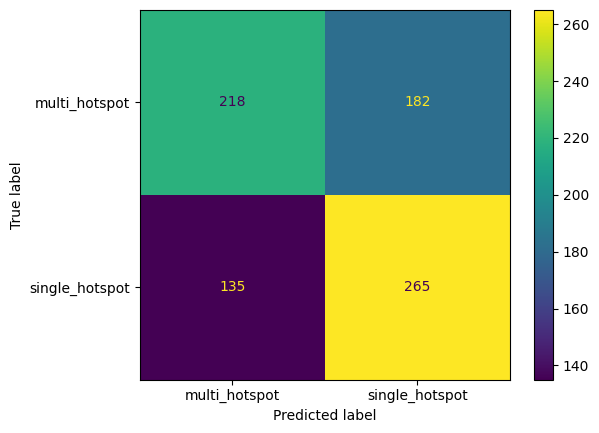

In [46]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_gen.class_indices.keys()))
disp.plot()
plt.show()

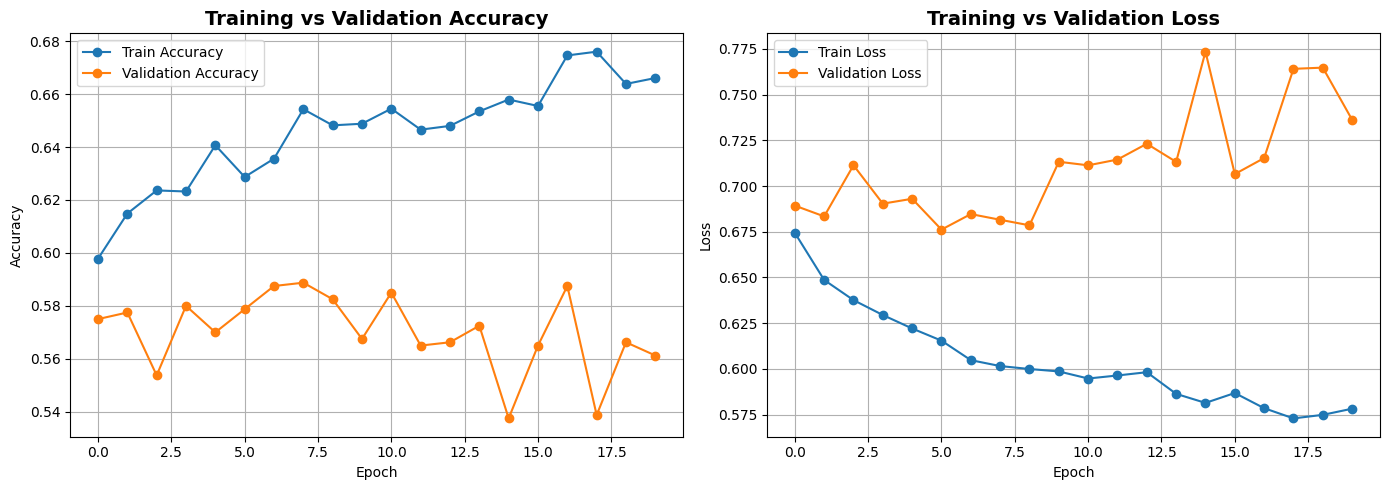

In [49]:
import matplotlib.pyplot as plt

# Plot accuracy and loss curves
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [53]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

In [54]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(), Precision(), Recall()]
)

In [55]:
model.fit(train_gen, validation_data=val_gen, epochs=10)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.6575 - auc_3: 0.7273 - loss: 0.6025 - precision_3: 0.5198 - recall_3: 0.7261 - val_accuracy: 0.5462 - val_auc_3: 0.5810 - val_loss: 0.7194 - val_precision_3: 0.5459 - val_recall_3: 0.5500
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 73s 944ms/step - accuracy: 0.6744 - auc_3: 0.7475 - loss: 0.5825 - precision_3: 0.5338 - recall_3: 0.7496 - val_accuracy: 0.5500 - val_auc_3: 0.5816 - val_loss: 0.7244 - val_precision_3: 0.5472 - val_recall_3: 0.5800
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 72s 937ms/step - accuracy: 0.6626 - auc_3: 0.7528 - loss: 0.5791 - precision_3: 0.5017 - recall_3: 0.7432 - val_accuracy: 0.5525 - val_auc_3: 0.5814 - val_loss: 0.7329 - val_precision_3: 0.5495 - val_recall_3: 0.5825
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 73s 941ms/step - accuracy: 0.6685 - auc_3: 0.7495 - loss: 0.5859 - precision_3: 0.5295 - recall_3: 0.7561 - val_accuracy: 0.5562 - val_auc_3: 0.5801 - val_loss: 0.7446 - val_precision_3: 0.5527 - val

KeyboardInterrupt: 